# Forum Data — Cleaning & EDA

**Dataset:** `forum_data.csv` — text scraped from two endometriosis-related web sources: the `endometriosis_org` news/forum pages and the `healthunlocked_endo` community forum.

**Scope of this notebook:**
1. Understand the columns and structure
2. Check for missing values (including "hidden" missing patterns)
3. Check for duplicates — both exact row duplicates and content-level duplicates that a plain equality check can't see
4. Clean the data
5. Explore the cleaned data (EDA)

**Not covered here (by design):** any model training or NLP feature extraction — this notebook stops at a clean, well-understood dataset.


## 1. Setup

In [1]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', 150)
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (9, 5)


## 2. Load and inspect the raw data

In [2]:
df_raw = pd.read_csv('forum_data.csv')
print(f"Shape: {df_raw.shape[0]} rows x {df_raw.shape[1]} columns")
df_raw.head(5)


Shape: 32 rows x 7 columns


,source,text,url,page,language,esi_label,symptom_id
0,endometriosis_org,News Defining standards for endometriosis follow-up and improvement of care 21 August 2026 The EndoFollowUpProject aims to define standards for en...,https://www.endometriosis.org/forums/?page=1,1,en,unlabelled,unknown
1,endometriosis_org,Defining standards for endometriosis follow-up and improvement of care 21 August 2026 The EndoFollowUpProject aims to define standards for endomet...,https://www.endometriosis.org/forums/?page=1,1,en,unlabelled,unknown
2,endometriosis_org,Behind the headlines: endometriosis and ovarian cancer 19 July 2024 What are the facts behind the headlines about endometriosis and risk of ovaria...,https://www.endometriosis.org/forums/?page=1,1,en,unlabelled,unknown
3,endometriosis_org,"Global study shows the experience of endometriosis is rooted in a person’s genetics 12 April 2023 DNA from 60,600 women with endometriosis reveals...",https://www.endometriosis.org/forums/?page=1,1,en,unlabelled,unknown
4,endometriosis_org,"Facts about endometriosis 10 March 2021 FACTS about endometriosis to aid journalists, medical writers, bloggers, etc, who wish to ensure their pub...",https://www.endometriosis.org/forums/?page=1,1,en,unlabelled,unknown


## 3. Columns

| Column | What it holds |
|---|---|
| `source` | Which site the row was scraped from (`endometriosis_org` or `healthunlocked_endo`) |
| `text` | The scraped text content itself |
| `url` | The page URL the text was scraped from |
| `page` | The pagination number of that URL |
| `language` | Detected/assigned language of the text |
| `esi_label` | An "Emergency Severity Index"-style label — placeholder for a future labeling task |
| `symptom_id` | An identifier linking text to a specific symptom — placeholder for a future labeling task |


In [3]:
df_raw.dtypes.to_frame(name='dtype')

,dtype
source,str
text,str
url,str
page,int64
language,str
esi_label,str
symptom_id,str


In [4]:
for col in df_raw.columns:
    print(f"{col}: {df_raw[col].nunique()} unique values")


source: 2 unique values
text: 32 unique values
url: 6 unique values
page: 5 unique values
language: 1 unique values
esi_label: 1 unique values
symptom_id: 1 unique values


## 4. Missing values check

The standard check (`isnull()`) is the first step, but with scraped data a second check matters just as much: **placeholder values that mean "not yet filled in," which are technically present strings but functionally missing.**


In [5]:
print("True NaNs per column:")
df_raw.isnull().sum().to_frame(name='missing_count')


True NaNs per column:


,missing_count
source,0
text,0
url,0
page,0
language,0
esi_label,0
symptom_id,0


In [6]:
# Blank / whitespace-only strings (missed by isnull())
text_cols = df_raw.select_dtypes(include='object').columns.tolist()
blank_counts = {col: (df_raw[col].astype(str).str.strip() == '').sum() for col in text_cols}
pd.Series(blank_counts, name='blank_string_count').to_frame()


/tmp/ipykernel_95/3071856112.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  text_cols = df_raw.select_dtypes(include='object').columns.tolist()


,blank_string_count
source,0
text,0
url,0
language,0
esi_label,0
symptom_id,0


In [7]:
# Constant / placeholder columns -- a column with only one unique value carries
# no information yet, which is a different (and easy to miss) kind of "missing"
for col in df_raw.columns:
    if df_raw[col].nunique() == 1:
        print(f"'{col}' is constant across all {len(df_raw)} rows: {df_raw[col].unique()[0]!r}")


'language' is constant across all 32 rows: 'en'
'esi_label' is constant across all 32 rows: 'unlabelled'
'symptom_id' is constant across all 32 rows: 'unknown'


**Findings:**
- No true `NaN`s and no blank strings anywhere — every cell has some content.
- Three columns are **entirely constant**, which is a different kind of "missing":
  - `language` is `"en"` for all 32 rows — no distinguishing information for this dataset.
  - `esi_label` is `"unlabelled"` for all 32 rows — a placeholder waiting for a future annotation step, not an error.
  - `symptom_id` is `"unknown"` for all 32 rows — same situation, a placeholder for future symptom tagging.

These are kept (not dropped — dropping them would lose the schema needed for future labeling) but flagged so they aren't mistaken for genuinely-analyzed fields.


## 5. Duplicate check

In [8]:
exact_dupes = df_raw.duplicated().sum()
text_dupes = df_raw['text'].duplicated().sum()
print(f"Fully duplicated rows: {exact_dupes}")
print(f"Rows with an exactly repeated 'text' value: {text_dupes}")


Fully duplicated rows: 0
Rows with an exactly repeated 'text' value: 0


On the surface that looks clean — but a plain equality check misses two content-level duplicate patterns that only show up when the text is actually read:

**5.1 Nested fragments.** Some rows are a complete forum post (title + question + latest reply, scraped as one block). Other rows are that *same* question, or that *same* reply, scraped again on their own — the page's HTML nests those pieces inside the post container, and the scraper captured both the container and its children. These aren't equal strings, so `duplicated()` misses them, but they describe **one real post, not several**.


In [9]:
def find_nested_fragments(data):
    """Return {parent_index: [fragment_indices]} for rows whose text
    fully contains one or more other rows' text within the same url group."""
    parent_to_fragments = {}
    for url, group in data.groupby('url'):
        texts = group['text'].tolist()
        idxs = group.index.tolist()
        for i, idx_i in enumerate(idxs):
            t_i = str(texts[i]).strip()
            fragments = [idxs[j] for j, idx_j in enumerate(idxs)
                         if i != j and str(texts[j]).strip()
                         and str(texts[j]).strip() in t_i
                         and len(str(texts[j]).strip()) < len(t_i)]
            if fragments:
                parent_to_fragments[idx_i] = fragments
    return parent_to_fragments

nested = find_nested_fragments(df_raw)
for parent, fragments in nested.items():
    print(f"Row {parent} fully contains rows {fragments}")


Row 0 fully contains rows [1, 2, 3, 4, 5]
Row 10 fully contains rows [11, 12]
Row 13 fully contains rows [14]
Row 15 fully contains rows [16]
Row 17 fully contains rows [18]
Row 19 fully contains rows [20, 21]
Row 26 fully contains rows [27]
Row 28 fully contains rows [29]
Row 30 fully contains rows [31]
Row 23 fully contains rows [24, 25]


In [10]:
# Concrete example of the pattern
example_parent = list(nested.keys())[1]
example_fragments = nested[example_parent]
print("PARENT (row", example_parent, "):\n", df_raw.loc[example_parent, 'text'], "\n")
for f in example_fragments:
    print("FRAGMENT (row", f, "):\n", df_raw.loc[f, 'text'], "\n")


PARENT (row 10 ):
 Umbilical Endometriosis Hi, I’ve not been formally diagnosed yet but I have been diagnosed with adenomyosis and fibroids. I have been suffering with a painful belly button. Which has... Latest reply by Dogmad6 • 1 hour ago Well unfortunately I still suffer with endometriosis but my surgeries greatly improved things for me. I live with it.  However, it's not in my umbilicus. That... 

FRAGMENT (row 11 ):
 Hi, I’ve not been formally diagnosed yet but I have been diagnosed with adenomyosis and fibroids. I have been suffering with a painful belly button. Which has... 

FRAGMENT (row 12 ):
 Latest reply by Dogmad6 • 1 hour ago Well unfortunately I still suffer with endometriosis but my surgeries greatly improved things for me. I live with it.  However, it's not in my umbilicus. That... 



**5.2 Cross-page repeats.** The HealthUnlocked forum shows a "featured" sidebar post on every results page. The scraper picked up that same post again each time it turned the page, with only its relative timestamp changing (*"7 minutes ago"* → *"8 minutes ago"* → …).


In [11]:
def normalize_timestamp(text):
    return re.sub(r'\d+\s+(minute|hour|day)s?\s+ago', '<TIME> ago', str(text)).strip()

df_raw['normalized_text'] = df_raw['text'].apply(normalize_timestamp)
cross_page_dupes = df_raw[df_raw.duplicated(subset='normalized_text', keep=False)].sort_values('normalized_text')
cross_page_dupes[['source', 'page', 'text']]


,source,page,text
23,healthunlocked_endo,6,Is anyone on mounjaro? Has anyone tried or is on mounjaro and has seen a difference with the endometriosis pain side of things? As im seeing more ...
26,healthunlocked_endo,16,Is anyone on mounjaro? Has anyone tried or is on mounjaro and has seen a difference with the endometriosis pain side of things? As im seeing more ...
28,healthunlocked_endo,32,Is anyone on mounjaro? Has anyone tried or is on mounjaro and has seen a difference with the endometriosis pain side of things? As im seeing more ...
30,healthunlocked_endo,48,Is anyone on mounjaro? Has anyone tried or is on mounjaro and has seen a difference with the endometriosis pain side of things? As im seeing more ...
25,healthunlocked_endo,6,Latest reply by Happyalam • 7 minutes ago Been on it 3 weeks now 6lb lost no problems so far
27,healthunlocked_endo,16,Latest reply by Happyalam • 8 minutes ago Been on it 3 weeks now 6lb lost no problems so far
29,healthunlocked_endo,32,Latest reply by Happyalam • 9 minutes ago Been on it 3 weeks now 6lb lost no problems so far
31,healthunlocked_endo,48,Latest reply by Happyalam • 10 minutes ago Been on it 3 weeks now 6lb lost no problems so far


**Decision:** for the nested fragments, keep the more complete "parent" row and drop its fragments (they add no information beyond what the parent already has). For the cross-page repeats, keep only the first occurrence of each normalized-text group and drop the rest.


## 6. Cleaning

In [12]:
df = df_raw.copy()

# Strip whitespace and cast types
for col in text_cols:
    df[col] = df[col].astype(str).str.strip()
df['page'] = df['page'].astype(int)

# Drop nested fragments (keep the complete "parent" row per post)
fragment_rows = sorted({f for frags in nested.values() for f in frags})
df = df.drop(index=fragment_rows).reset_index(drop=True)
print(f"Dropped {len(fragment_rows)} nested-fragment rows -> {len(df)} rows remain")

# Drop cross-page repeats (keep first occurrence)
df['normalized_text'] = df['text'].apply(normalize_timestamp)
before = len(df)
df = df.drop_duplicates(subset='normalized_text', keep='first').reset_index(drop=True)
print(f"Dropped {before - len(df)} cross-page repeat rows -> {len(df)} rows remain")

df = df.drop(columns=['normalized_text'])


Dropped 17 nested-fragment rows -> 15 rows remain
Dropped 3 cross-page repeat rows -> 12 rows remain


In [13]:
# Light, rule-based content tagging -- descriptive bookkeeping, not a classifier
def guess_content_type(text):
    t = text.lower()
    if 'cookie' in t and 'site functionality' in t:
        return 'cookie_notice'
    if re.search(r'\b(congress|conference|world congress)\b', t):
        return 'event_listing'
    if 'please do not name' in t or 'community guideline' in t:
        return 'community_guideline'
    if 'latest reply' in t or 'be the first to reply' in t:
        return 'forum_post'
    return 'news_or_other'

df['content_type'] = df['text'].apply(guess_content_type)
df['content_type'].value_counts().to_frame(name='count')


,count
content_type,
forum_post,6
event_listing,3
news_or_other,1
cookie_notice,1
community_guideline,1


## 7. Export the cleaned dataset

In [14]:
output_cols = ['source', 'text', 'url', 'page', 'content_type', 'language', 'esi_label', 'symptom_id']
df_final = df[output_cols]
df_final.to_csv('forum_data_cleaned.csv', index=False)
print(f"Saved forum_data_cleaned.csv — {len(df_final)} rows x {len(output_cols)} columns")
df_final


Saved forum_data_cleaned.csv — 12 rows x 8 columns


,source,text,url,page,content_type,language,esi_label,symptom_id
0,endometriosis_org,News Defining standards for endometriosis follow-up and improvement of care 21 August 2026 The EndoFollowUpProject aims to define standards for en...,https://www.endometriosis.org/forums/?page=1,1,news_or_other,en,unlabelled,unknown
1,endometriosis_org,Oct 23 Asian Congress of Endometriosis and Adenomyosis 2026 | Singapore,https://www.endometriosis.org/forums/?page=1,1,event_listing,en,unlabelled,unknown
2,endometriosis_org,"Oct 26 IASP 2026 World Congress on Pain | Bankok, Thailand",https://www.endometriosis.org/forums/?page=1,1,event_listing,en,unlabelled,unknown
3,endometriosis_org,"Jun 2 17th World Congress on Endometriosis | Istanbul, Turkey",https://www.endometriosis.org/forums/?page=1,1,event_listing,en,unlabelled,unknown
4,endometriosis_org,We use cookies to optimise site functionality and give you the best possible experience.,https://www.endometriosis.org/forums/?page=1,1,cookie_notice,en,unlabelled,unknown
5,healthunlocked_endo,"Umbilical Endometriosis Hi, I’ve not been formally diagnosed yet but I have been diagnosed with adenomyosis and fibroids. I have been suffering wi...",https://www.healthunlocked.com/endometriosis-uk?page=1,1,forum_post,en,unlabelled,unknown
6,healthunlocked_endo,endometriosis diagnosis and cartilage loss hi I was wondering if anyone else has been diagnosed with loss of cartilage leading to pain? My daughte...,https://www.healthunlocked.com/endometriosis-uk?page=1,1,forum_post,en,unlabelled,unknown
7,healthunlocked_endo,Experience with Desogestrel? I got diagnosed with endometriosis back in June this year and I got prescribed Desogestrel (birth control which is me...,https://www.healthunlocked.com/endometriosis-uk?page=1,1,forum_post,en,unlabelled,unknown
8,healthunlocked_endo,"What next Sorry for the long post.After years and years of irregular painfull heavy periods which I still have, in 2022 I started hrt tablets whic...",https://www.healthunlocked.com/endometriosis-uk?page=1,1,forum_post,en,unlabelled,unknown
9,healthunlocked_endo,"What next? I have recently been diagnosed with deep infiltrating endometriosis, adenomyosis, ovarian cysts and fibroids, and now trying to make a...",https://www.healthunlocked.com/endometriosis-uk?page=1,1,forum_post,en,unlabelled,unknown


## 8. EDA on the cleaned data

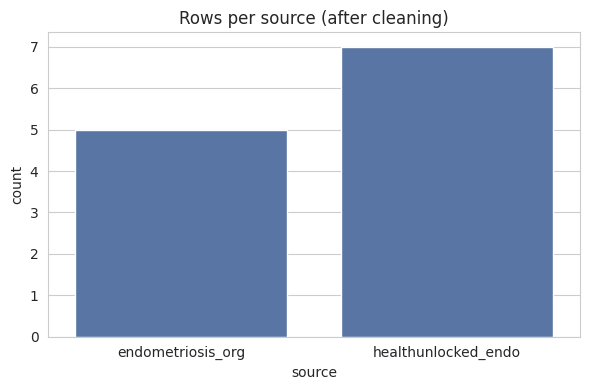

In [15]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df_final, x='source', color='#4C72B0')
plt.title('Rows per source (after cleaning)')
plt.tight_layout()
plt.show()


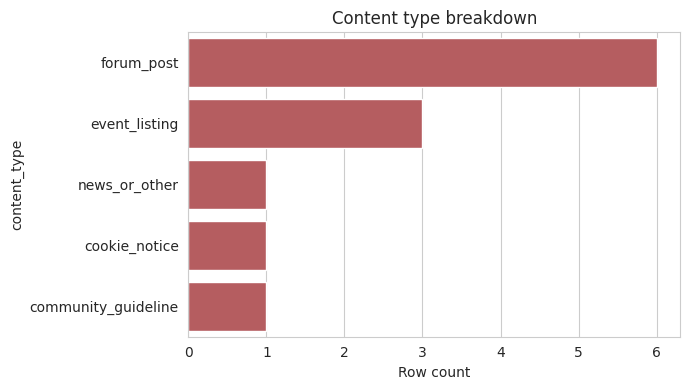

In [16]:
plt.figure(figsize=(7, 4))
counts = df_final['content_type'].value_counts()
sns.barplot(x=counts.values, y=counts.index, color='#C44E52')
plt.title('Content type breakdown')
plt.xlabel('Row count')
plt.tight_layout()
plt.show()


In [17]:
df_final = df_final.copy()
df_final['word_count'] = df_final['text'].str.split().str.len()
df_final[['source', 'content_type', 'page', 'word_count']].sort_values(['source', 'page'])


,source,content_type,page,word_count
0,endometriosis_org,news_or_other,1,157
1,endometriosis_org,event_listing,1,11
2,endometriosis_org,event_listing,1,11
3,endometriosis_org,event_listing,1,10
4,endometriosis_org,cookie_notice,1,14
5,healthunlocked_endo,forum_post,1,63
6,healthunlocked_endo,forum_post,1,43
7,healthunlocked_endo,forum_post,1,39
8,healthunlocked_endo,forum_post,1,40
9,healthunlocked_endo,forum_post,1,64


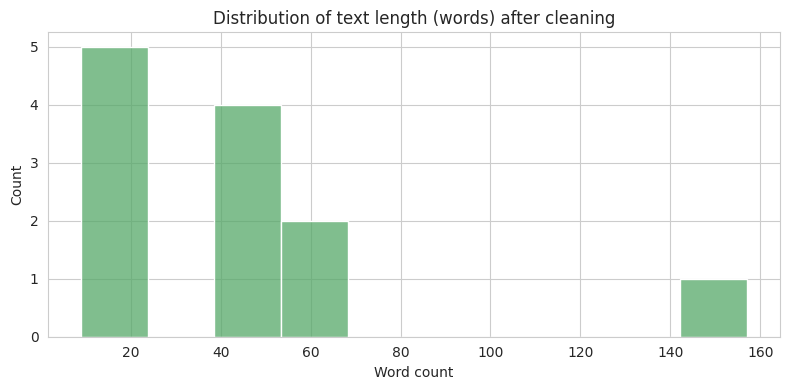

In [18]:
plt.figure(figsize=(8, 4))
sns.histplot(df_final['word_count'], bins=10, color='#55A868')
plt.title('Distribution of text length (words) after cleaning')
plt.xlabel('Word count')
plt.tight_layout()
plt.show()


**Findings:**
- After removing nested fragments and cross-page repeats, the dataset shrinks from 32 raw rows to a smaller set of distinct, complete records — each representing one real piece of content instead of a fragment or a repeat.
- The mix is genuinely varied: actual forum posts, news items, event listings, a cookie notice, and a community guideline notice — worth knowing before treating this as a clean "forum posts only" dataset, since a meaningful share of the distinct content isn't a forum post at all.
- Text length is short and fairly consistent across the cleaned rows compared to a full clinical document, consistent with forum/news snippets rather than long-form writing.


## 9. Summary

| Check | Result |
|---|---|
| Raw rows | 32 |
| True missing values | None |
| Blank strings | None |
| Constant/placeholder columns | `language` (`"en"`), `esi_label` (`"unlabelled"`), `symptom_id` (`"unknown"`) |
| Exact duplicate rows | None |
| Nested fragment rows removed | See Section 6 output above |
| Cross-page repeat rows removed | See Section 6 output above |
| **Rows in cleaned output** | See Section 6 output above |

**Not covered here (by design):** any NLP preprocessing or model training. `forum_data_cleaned.csv` is the clean, de-duplicated starting point for that work, not the work itself.
